In [5]:
from langgraph.graph import StateGraph, START, MessagesState, END
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import RemoveMessage
import os

In [6]:
load_dotenv()

True

In [7]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    google_api_key=os.getenv("GOOGLE_GENAI_KEY"),
)

In [39]:
def chat(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    response = llm.invoke(messages)

    return {
        "messages": [response]
    }

def delete_old_message(state: MessagesState) -> MessagesState:
    messages = state["messages"]
    print(len(messages))
    if len(messages) > 10:
        # Remove the oldest message
        to_remove = messages[:6]
        return {
            "messages" : [RemoveMessage(id =m.id) for m in to_remove]
        }
    return {}


In [40]:
builder = StateGraph(MessagesState)
builder.add_node("call_node", chat)
builder.add_node("delete_node", delete_old_message)

builder.add_edge(START, "call_node")
builder.add_edge("call_node", "delete_node")
builder.add_edge("delete_node", END)


In [41]:
checkpoint = InMemorySaver()
graph = builder.compile(checkpointer=checkpoint)

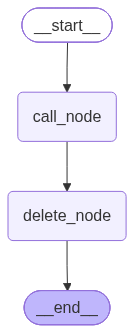

In [42]:
graph

In [43]:
config = {
    "configurable": {
        "thread_id": "thread_1"
    }
}

In [44]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name "}]},
    config=config
)
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name "}]},
    config=config
)
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name "}]},
    config=config
)
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name "}]},
    config=config
)
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name "}]},
    config=config
)
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name "}]},
    config=config
)
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name "}]},
    config=config
)
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name "}]},
    config=config
)


2
4
6
8
10
12
8
10


In [45]:
snap = graph.get_state(config)
print("Stored messages in state:", len(snap.values["messages"]))

Stored messages in state: 10
